In [1]:
import numpy as np
from scipy.io import loadmat
import h5py
from pathlib import Path
from matplotlib import pyplot as plt
import math

import pickle
positions = pickle.load(open('./data/position.pkl', 'rb'))

In [2]:
def time_correction(sensor, state, time, time_receive, c):

    dx, dy, dz, dist = distance(sensor.x, sensor.y, sensor.z, state.x, state.y, state.z)

    f = time + dist / c - time_receive
    df = 1 + (state.vx*dx + state.vy*dy + state.vz*dz) / (c * dist)
    time_correction = -f/df
    return time + time_correction

def make_chirp(start_time, duration, sample_time, doppler):
    f_min = 10
    f_max = 100
    Thalf = duration/2
    CR = (f_max - f_min)/Thalf

    t = sample_time - start_time

    if t < 0 or t > duration: # outside chirp
        return 0.0 # add noise
    
    elif t <= Thalf: # rising
        phase = 2*np.pi*((f_min+doppler)*t + 0.5*CR*t**2)
        
    else: # falling
        tau = t - duration/2
        phase_offset = f_min*Thalf + 0.5*CR*Thalf**2
        phase = 2*np.pi*(phase_offset + (f_max+doppler)*tau - 0.5*CR*tau**2)
    signal = np.sin(phase)

    return signal

def signal(time, epoch, interval, duration):
    # find preceding chirp start
    last_emit = epoch + np.floor(((time - epoch) / interval)) * interval
    sample = make_chirp(last_emit, duration, time, 0.0)
    return sample

def distance(x0, y0, z0, x1, y1, z1):
    dx = x0 - x1
    dy = y0 - y1
    dz = z0 - z1
    dist = math.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dist

class Channel:
    def __init__(self):
        self.gain = 1
        self.noise_magnitude = 0.1
        self.noise_standard_deviation = 0.05

    def apply(self, sample, distance):
        noise = self.noise_magnitude * np.random.normal(0.0, self.noise_standard_deviation) 
        attenuation = math.pow(distance, -2)
        return self.gain * (attenuation * sample + noise)

class Microphone:
    def __init__(self, x, y, z, channel):
        self.x = x
        self.y = y
        self.z = z
        self.channel = channel
        self.data = []
        self.timestamp = []

    def add_sample(self, time, sample):
        self.data.append(sample)
        self.timestamp.append(time)

    def display(self):
        plt.plot(self.timestamp, self.data)
        plt.xlabel(f'timestamp (s)')
        plt.ylabel(f'amplitude')
        

class State:
    def __init__(self, x, y, z, vx, vy, vz, ax, ay, az, timestamp):
        self.x = x
        self.y = y
        self.z = z
        self.vx = vx
        self.vy = vy
        self.vz = vz
        self.ax = ax
        self.ay = ay
        self.az = az
        self.timestamp = timestamp

class Target:
    def __init__(self, track):
        self.track_time = track[:, 0]
        self.track_y = track[:, 1]
        self.track_x = track[:, 2]
        self.track_z = np.zeros_like(self.track_x)

    def get_time_bounds(self):
        return self.track_time[5], self.track_time[-6]

    def get_state(self, time) -> State:
        idx = np.searchsorted(self.track_time, time, side='right') - 1

        # state is not established in model
        t0 = self.track_time[idx-1]
        t1 = self.track_time[idx]
        t2 = self.track_time[idx+1]

        x0 = self.track_x[idx-1]
        x1 = self.track_x[idx]
        x2 = self.track_x[idx+1]

        y0 = self.track_y[idx-1]
        y1 = self.track_y[idx]
        y2 = self.track_y[idx+1]

        d0 = (t0-t1)*(t0-t2)
        d1 = (t1-t0)*(t1-t2)
        d2 = (t2-t0)*(t2-t1)

        L0 = ((time-t1)*(time-t2)) / d0
        L1 = ((time-t0)*(time-t2)) / d1
        L2 = ((time-t0)*(time-t1)) / d2

        # position
        _x = x0*L0 + x1*L1 + x2*L2
        _y = y0*L0 + y1*L1 + y2*L2

        # first derivatives
        L0p = ((time-t2) + (time-t1)) / d0
        L1p = ((time-t2) + (time-t0)) / d1
        L2p = ((time-t1) + (time-t0)) / d2

        _vx = x0*L0p + x1*L1p + x2*L2p
        _vy = y0*L0p + y1*L1p + y2*L2p

        # second derivatives (constant)
        L0pp = 2 / d0
        L1pp = 2 / d1
        L2pp = 2 / d2

        _ax = x0*L0pp + x1*L1pp + x2*L2pp
        _ay = y0*L0pp + y1*L1pp + y2*L2pp

        return State(
            _x, _y, 0,
            _vx, _vy, 0,
            _ax, _ay, 0,
            time
        )

class ModelConfig:
    def __init__(self, sampling_rate):
        self.sampling_rate = sampling_rate
        self.epoch = 0
        self.emission_duration = 0.1 # 100ms
        self.emission_rate = 0.5 # 2hz
        self.speed_of_sound = 343 # Speed of sound in air in m/s

class Model:
    def __init__(self, config, target, sensor_array):
        self.config = config
        self.target = target
        self.sensor_array = sensor_array
        self.clock = target.get_time_bounds()[0]
        self.end_time = target.get_time_bounds()[1]


    def tick(self):
        self.clock += self.config.sampling_rate**-1


    def sample(self):
        current_state = self.target.get_state(self.clock)
        for sensor in self.sensor_array:# at sample
            
            state = current_state
            time = self.clock

            # 2 iterations gets us to 10e-8 error
            num_iters = 2
            for iter in range(num_iters):
                time = time_correction(sensor, state, time, self.clock, self.config.speed_of_sound)
                state = self.target.get_state(time)

            _, _, _, dist = distance(sensor.x, sensor.y, sensor.z, state.x, state.y, state.z)
            sample = signal(time, self.config.epoch, self.config.emission_rate, self.config.emission_duration)
            sample = sensor.channel.apply(sample, dist)
            sensor.add_sample(self.clock, sample)


In [3]:
config = ModelConfig(sampling_rate=10000)

target = Target(positions)

microphone_array = [Microphone(7, 4, 0, Channel()),
                    Microphone(4, -3, 0, Channel()),
                    Microphone(-4, 5, 0, Channel()),
                    Microphone(-4, -6, 0, Channel())]


model = Model(config, target, microphone_array)

for i in range(60000):
    model.tick()
    model.sample()

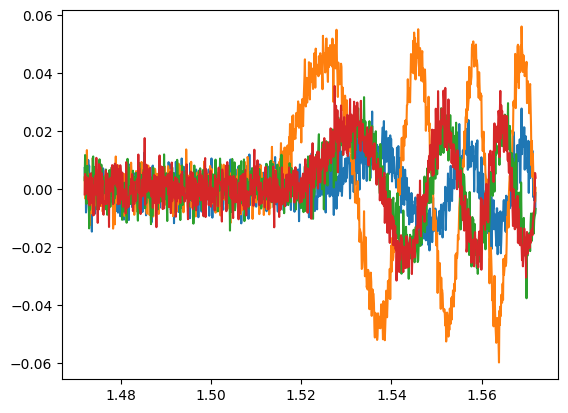

In [5]:
# model.sensor_array[0].display()
n = 9000
N = 10000
plt.plot(model.sensor_array[0].timestamp[n:N], model.sensor_array[0].data[n:N])
plt.plot(model.sensor_array[1].timestamp[n:N], model.sensor_array[1].data[n:N])
plt.plot(model.sensor_array[2].timestamp[n:N], model.sensor_array[2].data[n:N])
plt.plot(model.sensor_array[3].timestamp[n:N], model.sensor_array[3].data[n:N])

In [ ]:
target = Target()

microphone_1 = Microphone(4, 4, 0, Channel(), target)
microphone_2 = Microphone(4, -4, 0, Channel(), target)
microphone_3 = Microphone(-4, 4, 0, Channel(), target)
microphone_4 = Microphone(-4, -4, 0, Channel(), target)

while True:
    ret = target.update()
    if ret == 0:
        break   

    microphone_1.sample(target, emit=(ret == 2))
    microphone_2.sample(target, emit=(ret == 2))
    microphone_3.sample(target, emit=(ret == 2))
    microphone_4.sample(target, emit=(ret == 2))

pickle.dump(microphone_1, open('./data/microphone_1.pkl', 'wb'))
pickle.dump(microphone_2, open('./data/microphone_2.pkl', 'wb'))
pickle.dump(microphone_3, open('./data/microphone_3.pkl', 'wb'))
pickle.dump(microphone_4, open('./data/microphone_4.pkl', 'wb'))

In [ ]:
from scipy.signal import fftconvolve

microphone_1 = pickle.load(open('./data/microphone_1.pkl', 'rb'))
microphone_2 = pickle.load(open('./data/microphone_2.pkl', 'rb'))
microphone_3 = pickle.load(open('./data/microphone_3.pkl', 'rb'))
microphone_4 = pickle.load(open('./data/microphone_4.pkl', 'rb'))

def find_pulse_times(microphone, threshold):
    template = Chirp(microphone_1.sampling_rate, microphone_1.dt).make()
    matched_filter = template[::-1]
    data = microphone_1.data
    time = microphone_1.timestamps

    corr = fftconvolve(data, matched_filter, mode='valid')
    M = len(template)

    pulse_times = []

    t_start  = time[:len(corr)]                  # window start time
    # t_center = time[M//2 : M//2 + len(corr)]     # window center time (usually best)
    # t_end    = time[M-1 : M-1 + len(corr)]       # window end time
    pulse_times = t_start[corr > threshold]

    return pulse_times


toa_mic_1 = find_pulse_times(microphone_1, threshold=4e5)
toa_mic_2 = find_pulse_times(microphone_2, threshold=4e5)
toa_mic_3 = find_pulse_times(microphone_3, threshold=4e5)
toa_mic_4 = find_pulse_times(microphone_4, threshold=4e5)

plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(microphone_1.timestamps, microphone_1.data)
plt.plot(toa_mic_1, [0] * len(toa_mic_1), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(412)
plt.plot(microphone_2.timestamps, microphone_2.data)
plt.plot(toa_mic_2, [0] * len(toa_mic_2), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(413)
plt.plot(microphone_3.timestamps, microphone_3.data)
plt.plot(toa_mic_3, [0] * len(toa_mic_3), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(414)
plt.plot(microphone_4.timestamps, microphone_4.data)
plt.plot(toa_mic_4, [0] * len(toa_mic_4), 'or')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

pickle.dump(toa_mic_1, open('./data/toa_mic_1.pkl', 'wb'))
pickle.dump(toa_mic_2, open('./data/toa_mic_2.pkl', 'wb'))
pickle.dump(toa_mic_3, open('./data/toa_mic_3.pkl', 'wb'))
pickle.dump(toa_mic_4, open('./data/toa_mic_4.pkl', 'wb'))

In [ ]:
plt.figure(figsize=(12, 10))

start = 0
stop = 102000

plt.subplot(411)
plt.plot(microphone_1.timestamps[start:stop], microphone_1.data[start:stop])
plt.subplot(412)
plt.plot(microphone_2.timestamps[start:stop], microphone_2.data[start:stop])
plt.subplot(413)
plt.plot(microphone_3.timestamps[start:stop], microphone_3.data[start:stop])
plt.subplot(414)
plt.plot(microphone_4.timestamps[start:stop], microphone_4.data[start:stop])

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
target = Target()
x = []
y = []
time = []
while (target.update()):
    x.append(target.x)
    y.append(target.y)
    time.append(target.clock)


plt.plot(target.track_x, target.track_y, 'o')
plt.plot(x, y)

# plt.figure()
# plt.plot(target.track_time, target.track_x, 'o')
# plt.plot(time, x)

# plt.figure()
# plt.plot(target.track_time, target.track_y, 'o')
# plt.plot(time, y)


plt.plot([4],[4], 'rx')
plt.plot([4],[-4], 'rx')
plt.plot([-4],[4], 'rx')
plt.plot([-4],[-4], 'rx')